# Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded.")
print("TensorFlow version:", tf.__version__)

Libraries loaded.
TensorFlow version: 2.21.0


# Load MovieLens Dataset

In [2]:
ratings = pd.read_csv("ratings.csv")   # or rating.csv
movies = pd.read_csv("movies.csv")     # or movie.csv

print("Ratings shape:", ratings.shape)
print("Movies shape :", movies.shape)

print("\nRatings columns:")
print(ratings.columns.tolist())

print("\nMovies columns:")
print(movies.columns.tolist())

display(ratings.head())
display(movies.head())

Ratings shape: (1000209, 4)
Movies shape : (3883, 3)

Ratings columns:
['UserID', 'MovieID', 'Rating', 'Timestamp']

Movies columns:
['MovieID', 'Title', 'Genres']


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


# Standardize and select columns

In [3]:
ratings.columns = [c.strip().lower() for c in ratings.columns]
movies.columns = [c.strip().lower() for c in movies.columns]

# Rename if needed
rename_map = {}
if "userid" not in ratings.columns and "userid" in ratings.columns:
    rename_map["userid"] = "user_id"
if "movieid" not in ratings.columns and "movieid" in ratings.columns:
    rename_map["movieid"] = "item_id"

# Common MovieLens names after lowercase
if "userid" in ratings.columns:
    ratings = ratings.rename(columns={"userid": "user_id"})
if "movieid" in ratings.columns:
    ratings = ratings.rename(columns={"movieid": "item_id"})
if "rating" in ratings.columns:
    ratings = ratings.rename(columns={"rating": "star_rating"})
if "timestamp" in ratings.columns:
    ratings = ratings.rename(columns={"timestamp": "event_time"})

if "movieid" in movies.columns:
    movies = movies.rename(columns={"movieid": "item_id"})

required_cols = ["user_id", "item_id", "star_rating", "event_time"]
missing = [c for c in required_cols if c not in ratings.columns]
if missing:
    raise ValueError(f"Missing required columns in ratings file: {missing}")

df = ratings[required_cols].dropna().copy()

print("Cleaned ratings shape:", df.shape)
display(df.head())

Cleaned ratings shape: (1000209, 4)


,user_id,item_id,star_rating,event_time
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


# Convert time and encode users/items

In [4]:
df["event_time"] = pd.to_datetime(df["event_time"], unit="s", errors="coerce")
df = df.dropna(subset=["event_time"]).copy()

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df["user_idx"] = user_encoder.fit_transform(df["user_id"])
df["item_idx"] = item_encoder.fit_transform(df["item_id"])

n_users = df["user_idx"].nunique()
n_items = df["item_idx"].nunique()

print("Users:", n_users)
print("Items:", n_items)
print("Rows :", len(df))
print("Date range:", df["event_time"].min(), "to", df["event_time"].max())

Users: 6040
Items: 3706
Rows : 1000209
Date range: 2000-04-25 23:05:32 to 2003-02-28 17:49:50


# Create normalized numeric features

In [5]:
# user review count
user_review_counts = df.groupby("user_idx").size().rename("user_review_count")
df = df.merge(user_review_counts, on="user_idx", how="left")

# item review count
item_review_counts = df.groupby("item_idx").size().rename("item_review_count")
df = df.merge(item_review_counts, on="item_idx", how="left")

# user mean rating
user_mean_rating = df.groupby("user_idx")["star_rating"].mean().rename("user_mean_rating")
df = df.merge(user_mean_rating, on="user_idx", how="left")

# item mean rating
item_mean_rating = df.groupby("item_idx")["star_rating"].mean().rename("item_mean_rating")
df = df.merge(item_mean_rating, on="item_idx", how="left")

# deviation features
df["user_rating_deviation"] = (df["star_rating"] - df["user_mean_rating"]).abs()
df["item_rating_deviation"] = (df["star_rating"] - df["item_mean_rating"]).abs()

# normalize selected numeric columns
scaler = MinMaxScaler()

norm_cols = [
    "user_review_count",
    "item_review_count",
    "user_mean_rating",
    "item_mean_rating",
    "user_rating_deviation",
    "item_rating_deviation"
]

df[norm_cols] = df[norm_cols].fillna(0)

df[[
    "user_review_count_norm",
    "item_review_count_norm",
    "user_mean_rating_norm",
    "item_mean_rating_norm",
    "user_rating_deviation_norm",
    "item_rating_deviation_norm"
]] = scaler.fit_transform(df[norm_cols])

# rating normalization
df["rating_norm"] = (df["star_rating"] - 1.0) / 4.0

# time normalization
min_date = df["event_time"].min()
max_date = df["event_time"].max()

df["time_norm"] = (
    (df["event_time"] - min_date).dt.total_seconds() /
    (max_date - min_date).total_seconds()
).astype(np.float32)

display(df.head())

,user_id,item_id,star_rating,event_time,user_idx,item_idx,user_review_count,item_review_count,user_mean_rating,item_mean_rating,user_rating_deviation,item_rating_deviation,user_review_count_norm,item_review_count_norm,user_mean_rating_norm,item_mean_rating_norm,user_rating_deviation_norm,item_rating_deviation_norm,rating_norm,time_norm
0,1,1193,5,2000-12-31 22:12:40,0,1104,53,1725,4.188679,4.390725,0.811321,0.609275,0.014385,0.503064,0.803859,0.847681,0.208517,0.171120,1.00,0.240631
1,1,661,3,2000-12-31 22:35:09,0,639,53,525,4.188679,3.464762,1.188679,0.464762,0.014385,0.152903,0.803859,0.616190,0.305502,0.130532,0.50,0.240646
2,1,914,3,2000-12-31 22:32:48,0,853,53,636,4.188679,4.154088,1.188679,1.154088,0.014385,0.185293,0.803859,0.788522,0.305502,0.324136,0.50,0.240645
3,1,3408,4,2000-12-31 22:04:35,0,3177,53,1315,4.188679,3.863878,0.188679,0.136122,0.014385,0.383426,0.803859,0.715970,0.048492,0.038231,0.75,0.240626
4,1,2355,5,2001-01-06 23:38:11,0,2162,53,1703,4.188679,3.854375,0.811321,1.145625,0.014385,0.496644,0.803859,0.713594,0.208517,0.321759,1.00,0.246465


# Build feedback types

In [6]:
def assign_feedback_type(r):
    if r >= 5:
        return "ep"   # explicit positive
    elif r <= 1:
        return "en"   # explicit negative
    elif r in [3, 4]:
        return "ip"   # implicit positive
    else:
        return "in"   # implicit negative

df["feedback_type"] = df["star_rating"].apply(assign_feedback_type)

print(df["feedback_type"].value_counts())

feedback_type
ip    610168
ep    226310
in    107557
en     56174
Name: count, dtype: int64


# Create Target

In [7]:
df["target"] = (df["star_rating"] >= 4).astype(int)

print(df["target"].value_counts())

target
1    575281
0    424928
Name: count, dtype: int64


# Build per-user sequences

In [8]:
df = df.sort_values(["user_idx", "event_time"]).reset_index(drop=True)

MAX_LEN = 20

def pad_or_truncate(seq, max_len=20):
    seq = seq[-max_len:]
    if len(seq) < max_len:
        seq = [0] * (max_len - len(seq)) + seq
    return seq

user_sequences = {}

for user, grp in df.groupby("user_idx"):
    grp = grp.sort_values("event_time")
    user_sequences[user] = {
        "ip": grp.loc[grp["feedback_type"] == "ip", "item_idx"].tolist(),
        "in": grp.loc[grp["feedback_type"] == "in", "item_idx"].tolist(),
        "ep": grp.loc[grp["feedback_type"] == "ep", "item_idx"].tolist(),
        "en": grp.loc[grp["feedback_type"] == "en", "item_idx"].tolist()
    }

seq_rows = []
for user, seqs in user_sequences.items():
    seq_rows.append({
        "user_idx": user,
        "ip_seq": pad_or_truncate(seqs["ip"], MAX_LEN),
        "in_seq": pad_or_truncate(seqs["in"], MAX_LEN),
        "ep_seq": pad_or_truncate(seqs["ep"], MAX_LEN),
        "en_seq": pad_or_truncate(seqs["en"], MAX_LEN)
    })

seq_df = pd.DataFrame(seq_rows)
display(seq_df.head())

,user_idx,ip_seq,in_seq,ep_seq,en_seq
0,0,"[2592, 2557, 1154, 639, 2710, 517, 2898, 2586,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1178, 957, 1658, 2599, 1104, 1781, 1848...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,"[1273, 2296, 1286, 737, 159, 445, 1631, 2674, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1123, 1018, 1788, ...","[1106, 1777, 859, 1782, 3238, 1167, 1774, 1618...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,"[1120, 1199, 1449, 466, 1826, 632, 2277, 1934,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1174, 1279, 3429, 253, 1107, 1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1120, 1025, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3235, 253, 1108...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,"[501, 1569, 1506, 3243, 1625, 1449, 492, 367, ...","[144, 2744, 347, 398, 1516, 5, 1786, 1176, 315...","[2785, 2162, 2400, 852, 2202, 2144, 980, 2867,...","[0, 2512, 346, 1050, 2007, 2897, 23, 3280, 350..."


# User-Level features

In [9]:
user_features = df.groupby("user_idx").agg(
    avg_rating=("star_rating", "mean"),
    avg_user_dev=("user_rating_deviation_norm", "mean"),
    avg_item_dev=("item_rating_deviation_norm", "mean"),
    avg_time=("time_norm", "mean"),
    user_review_count=("user_review_count_norm", "mean")
).reset_index()

feedback_counts = df.pivot_table(
    index="user_idx",
    columns="feedback_type",
    values="item_idx",
    aggfunc="count",
    fill_value=0
).reset_index()

feedback_counts.columns.name = None

for col in ["ep", "en", "ip", "in"]:
    if col not in feedback_counts.columns:
        feedback_counts[col] = 0

user_features = user_features.merge(feedback_counts, on="user_idx", how="left")
display(user_features.head())

,user_idx,avg_rating,avg_user_dev,avg_item_dev,avg_time,user_review_count,en,ep,in,ip
0,0,4.188679,0.141634,0.179812,0.242068,0.014385,0,18,0,35
1,1,3.713178,0.218908,0.198727,0.240615,0.047515,2,34,11,82
2,2,3.901961,0.187742,0.217177,0.240598,0.013514,1,15,4,31
3,3,4.190476,0.198148,0.207353,0.240558,0.000436,1,10,1,9
4,4,3.146465,0.236215,0.265743,0.240005,0.077594,19,21,36,122


# Trusted neighbors using user profiles

In [10]:
profile_cols = ["avg_rating", "avg_user_dev", "avg_item_dev", "avg_time", "user_review_count", "ep", "en", "ip", "in"]

user_profiles = user_features.set_index("user_idx")[profile_cols].fillna(0)
sim_matrix = cosine_similarity(user_profiles.values)

TOP_K = 5
trusted_neighbors = {}
user_ids = user_profiles.index.tolist()

for i, uid in enumerate(user_ids):
    sims = sim_matrix[i].copy()
    sims[i] = -1
    top_idx = np.argsort(sims)[-TOP_K:][::-1]
    trusted_neighbors[uid] = [(user_ids[j], sims[j]) for j in top_idx if sims[j] > 0]

print("Example trusted neighbors:")
print(list(trusted_neighbors.items())[:3])

Example trusted neighbors:
[(0, [(1904, np.float64(0.9999363980656465)), (5741, np.float64(0.9999296561663995)), (4030, np.float64(0.9996314080460023)), (2519, np.float64(0.999532258175275)), (2364, np.float64(0.999325596636754))]), (1, [(4218, np.float64(0.9998479104282009)), (347, np.float64(0.999840121119416)), (2309, np.float64(0.999771615910542)), (2434, np.float64(0.9997305182266067)), (1419, np.float64(0.9996966444962448))]), (2, [(5586, np.float64(0.9998393896080802)), (943, np.float64(0.9997404836167533)), (5384, np.float64(0.999594379613295)), (4859, np.float64(0.9995659713051712)), (79, np.float64(0.9994742771810745))])]


# Neighbor aggregated features

In [11]:
neighbor_rows = []

for uid in user_ids:
    nbrs = trusted_neighbors.get(uid, [])
    if len(nbrs) == 0:
        neighbor_rows.append({
            "user_idx": uid,
            "nbr_avg_rating": 0.0,
            "nbr_avg_user_dev": 0.0,
            "nbr_avg_item_dev": 0.0
        })
        continue

    weights = np.array([max(w, 0) for _, w in nbrs], dtype=float)
    if weights.sum() == 0:
        weights = np.ones(len(nbrs))
    weights = weights / weights.sum()

    nbr_ids = [n for n, _ in nbrs]
    nbr_df = user_features[user_features["user_idx"].isin(nbr_ids)].set_index("user_idx").loc[nbr_ids]

    neighbor_rows.append({
        "user_idx": uid,
        "nbr_avg_rating": np.sum(nbr_df["avg_rating"].values * weights),
        "nbr_avg_user_dev": np.sum(nbr_df["avg_user_dev"].values * weights),
        "nbr_avg_item_dev": np.sum(nbr_df["avg_item_dev"].values * weights)
    })

neighbor_features = pd.DataFrame(neighbor_rows)
display(neighbor_features.head())

,user_idx,nbr_avg_rating,nbr_avg_user_dev,nbr_avg_item_dev
0,0,4.113444,0.153795,0.167747
1,1,3.781699,0.204215,0.192898
2,2,3.912676,0.182400,0.182320
3,3,4.108133,0.210680,0.207588
4,4,3.137477,0.224816,0.221369


# Merge everything into model table

In [12]:
model_df = df.merge(seq_df, on="user_idx", how="left")
model_df = model_df.merge(user_features, on="user_idx", how="left")
model_df = model_df.merge(neighbor_features, on="user_idx", how="left")

print(model_df.shape)
display(model_df.head())

(1000209, 38)


,user_id,item_id,star_rating,event_time,user_idx,item_idx,user_review_count_x,item_review_count,user_mean_rating,item_mean_rating,...,avg_item_dev,avg_time,user_review_count_y,en,ep,in,ip,nbr_avg_rating,nbr_avg_user_dev,nbr_avg_item_dev
0,1,3186,4,2000-12-31 22:00:19,0,2969,53,431,4.188679,3.477958,...,0.179812,0.242068,0.014385,0,18,0,35,4.113444,0.153795,0.167747
1,1,1270,5,2000-12-31 22:00:55,0,1178,53,2583,4.188679,3.990321,...,0.179812,0.242068,0.014385,0,18,0,35,4.113444,0.153795,0.167747
2,1,1721,4,2000-12-31 22:00:55,0,1574,53,1546,4.188679,3.583441,...,0.179812,0.242068,0.014385,0,18,0,35,4.113444,0.153795,0.167747
3,1,1022,5,2000-12-31 22:00:55,0,957,53,577,4.188679,3.755633,...,0.179812,0.242068,0.014385,0,18,0,35,4.113444,0.153795,0.167747
4,1,2340,3,2000-12-31 22:01:43,0,2147,53,344,4.188679,3.252907,...,0.179812,0.242068,0.014385,0,18,0,35,4.113444,0.153795,0.167747


# Train / Test Split

In [13]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42,
    stratify=model_df["target"]
)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (800167, 38)
Test : (200042, 38)


# Prepare model inputs

In [14]:
def make_inputs(frame):
    return {
        "user_idx": frame["user_idx"].values.astype(np.int32),
        "item_idx": frame["item_idx"].values.astype(np.int32),

        "ip_seq": np.stack(frame["ip_seq"].values).astype(np.int32),
        "in_seq": np.stack(frame["in_seq"].values).astype(np.int32),
        "ep_seq": np.stack(frame["ep_seq"].values).astype(np.int32),
        "en_seq": np.stack(frame["en_seq"].values).astype(np.int32),

        "user_review_count_norm": frame["user_review_count_norm"].values.astype(np.float32),
        "item_review_count_norm": frame["item_review_count_norm"].values.astype(np.float32),
        "user_mean_rating_norm": frame["user_mean_rating_norm"].values.astype(np.float32),
        "item_mean_rating_norm": frame["item_mean_rating_norm"].values.astype(np.float32),
        "user_rating_deviation_norm": frame["user_rating_deviation_norm"].values.astype(np.float32),
        "item_rating_deviation_norm": frame["item_rating_deviation_norm"].values.astype(np.float32),
        "rating_norm": frame["rating_norm"].values.astype(np.float32),
        "time_norm": frame["time_norm"].values.astype(np.float32),

        "avg_rating": frame["avg_rating"].values.astype(np.float32),
        "avg_user_dev": frame["avg_user_dev"].values.astype(np.float32),
        "avg_item_dev": frame["avg_item_dev"].values.astype(np.float32),
        "nbr_avg_rating": frame["nbr_avg_rating"].values.astype(np.float32),
        "nbr_avg_user_dev": frame["nbr_avg_user_dev"].values.astype(np.float32),
        "nbr_avg_item_dev": frame["nbr_avg_item_dev"].values.astype(np.float32)
    }

X_train = make_inputs(train_df)
X_test = make_inputs(test_df)

y_train = train_df["target"].values.astype(np.float32)
y_test = test_df["target"].values.astype(np.float32)

# Build Model

In [16]:
EMBED_DIM = 32
LSTM_UNITS = 32

def build_movielens_model(n_users, n_items, max_len=20, embed_dim=32, lstm_units=32):
    user_in = layers.Input(shape=(1,), name="user_idx")
    item_in = layers.Input(shape=(1,), name="item_idx")

    ip_seq_in = layers.Input(shape=(max_len,), name="ip_seq")
    in_seq_in = layers.Input(shape=(max_len,), name="in_seq")
    ep_seq_in = layers.Input(shape=(max_len,), name="ep_seq")
    en_seq_in = layers.Input(shape=(max_len,), name="en_seq")

    numeric_names = [
        "user_review_count_norm", "item_review_count_norm",
        "user_mean_rating_norm", "item_mean_rating_norm",
        "user_rating_deviation_norm", "item_rating_deviation_norm",
        "rating_norm", "time_norm",
        "avg_rating", "avg_user_dev", "avg_item_dev",
        "nbr_avg_rating", "nbr_avg_user_dev", "nbr_avg_item_dev"
    ]

    numeric_inputs = [layers.Input(shape=(1,), name=n) for n in numeric_names]

    user_emb = layers.Embedding(n_users + 1, embed_dim)(user_in)
    user_emb = layers.Flatten()(user_emb)

    item_emb = layers.Embedding(n_items + 1, embed_dim)(item_in)
    item_emb = layers.Flatten()(item_emb)

    seq_emb = layers.Embedding(n_items + 1, embed_dim, mask_zero=True)

    ip_enc = layers.LSTM(lstm_units)(seq_emb(ip_seq_in))
    in_enc = layers.LSTM(lstm_units)(seq_emb(in_seq_in))
    ep_enc = layers.LSTM(lstm_units)(seq_emb(ep_seq_in))
    en_enc = layers.LSTM(lstm_units)(seq_emb(en_seq_in))

    pos_fused = layers.Concatenate()([ip_enc, ep_enc])
    pos_fused = layers.Dense(64, activation="relu")(pos_fused)

    neg_fused = layers.Concatenate()([in_enc, en_enc])
    neg_fused = layers.Dense(64, activation="relu")(neg_fused)

    numeric_concat = layers.Concatenate()(numeric_inputs)
    numeric_dense = layers.Dense(64, activation="relu")(numeric_concat)

    x = layers.Concatenate()([user_emb, item_emb, pos_fused, neg_fused, numeric_dense])
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(
        inputs=[user_in, item_in, ip_seq_in, in_seq_in, ep_seq_in, en_seq_in] + numeric_inputs,
        outputs=out
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model

model = build_movielens_model(n_users=n_users, n_items=n_items, max_len=MAX_LEN, embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ip_seq (InputLayer)           │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ep_seq (InputLayer)           │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ in_seq (InputLayer)           │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ en_seq (InputLayer)           │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_5 (Embedding)       │ (None, 20, 32)            │         118,624 │ ip_seq[0][0],              │
│                               │                           │                 │ in_seq[0][0],              │
│                               │                           │                 │ ep_seq[0][0], en_seq[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_4 (NotEqual)        │ (None, 20)                │               0 │ ip_seq[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_6 (NotEqual)        │ (None, 20)                │               0 │ ep_seq[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_5 (NotEqual)        │ (None, 20)                │               0 │ in_seq[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_7 (NotEqual)        │ (None, 20)                │               0 │ en_seq[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_idx (InputLayer)         │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ item_idx (InputLayer)         │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_4 (LSTM)                 │ (None, 32)                │           8,320 │ embedding_5[0][0],         │
│                               │                           │                 │ not_equal_4[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_6 (LSTM)                 │ (None, 32)                │           8,320 │ embedding_5[2][0],         │
│                               │                           │                 │ not_equal_6[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_5 (LSTM)                 │ (None, 32)                │           8,320 │ embedding_5[1][0],         │
│                               │                           │                 │ not_equal_5[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_7 (LSTM)                 │ (None, 32)                │           8,32

 Total params: 514,337 (1.96 MB)

 Trainable params: 514,337 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
1028/3126 ━━━━━━━━━━━━━━━━━━━━ 4:03 116ms/step - auc: 0.9720 - loss: 0.1418

# Evaluate model

In [19]:
callbacks = [
    EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 226s 72ms/step - auc: 1.0000 - loss: 1.2921e-06 - val_auc: 1.0000 - val_loss: 8.0646e-09 - learning_rate: 2.5000e-04
Epoch 2/10
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 260s 72ms/step - auc: 1.0000 - loss: 7.7655e-07 - val_auc: 1.0000 - val_loss: 3.8160e-09 - learning_rate: 2.5000e-04
Epoch 3/10
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - auc: 1.0000 - loss: 5.2785e-07  
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 223s 71ms/step - auc: 1.0000 - loss: 4.4074e-07 - val_auc: 1.0000 - val_loss: 9.5818e-10 - learning_rate: 2.5000e-04
Epoch 4/10
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 267s 85ms/step - auc: 1.0000 - loss: 1.5205e-07 - val_auc: 1.0000 - val_loss: 3.1376e-10 - learning_rate: 1.2500e-04


# Noise Sensitivity on MovieLens

In [21]:
preds = model.predict(X_test).ravel()
auc_score = roc_auc_score(y_test, preds)

print("Test AUC:", round(auc_score, 4))

6252/6252 ━━━━━━━━━━━━━━━━━━━━ 86s 13ms/step 
Test AUC: 1.0


In [22]:
test_eval = test_df.copy()
test_eval["pred"] = preds

median_dev = test_eval["user_rating_deviation_norm"].median()

low_noise_mask = test_eval["user_rating_deviation_norm"] <= median_dev
high_noise_mask = test_eval["user_rating_deviation_norm"] > median_dev

low_noise_auc = roc_auc_score(
    test_eval.loc[low_noise_mask, "target"],
    test_eval.loc[low_noise_mask, "pred"]
)

high_noise_auc = roc_auc_score(
    test_eval.loc[high_noise_mask, "target"],
    test_eval.loc[high_noise_mask, "pred"]
)

print("AUC on lower-deviation interactions :", round(low_noise_auc, 4))
print("AUC on higher-deviation interactions:", round(high_noise_auc, 4))

AUC on lower-deviation interactions : 1.0
AUC on higher-deviation interactions: 1.0


# Training Curves

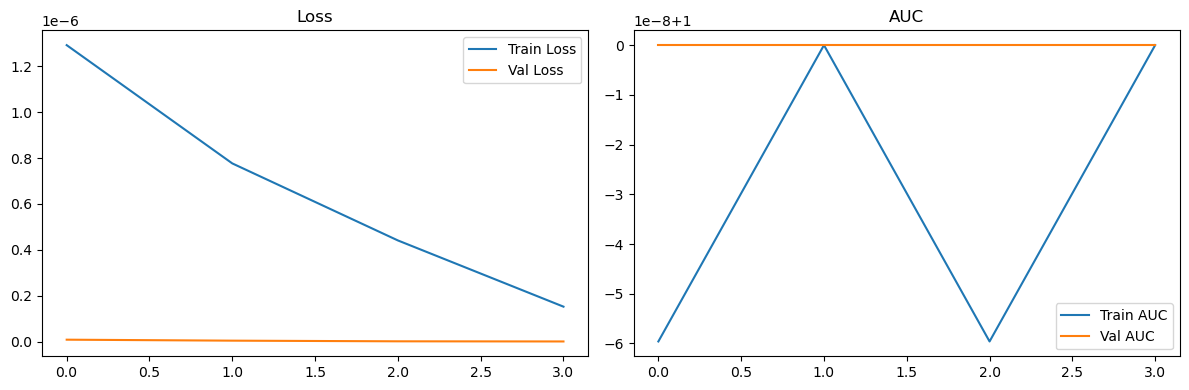

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.title("AUC")
plt.legend()

plt.tight_layout()
plt.show()

# Final Summary

In [24]:
print("=" * 60)
print("MOVIELENS MODEL SUMMARY")
print("=" * 60)
print("Dataset shape:", df.shape)
print("Users:", n_users)
print("Items:", n_items)
print("Feedback types:")
print(df["feedback_type"].value_counts())
print("\nFinal Test AUC:", round(auc_score, 4))
print("Low-deviation AUC :", round(low_noise_auc, 4))
print("High-deviation AUC:", round(high_noise_auc, 4))
print("=" * 60)

MOVIELENS MODEL SUMMARY
Dataset shape: (1000209, 22)
Users: 6040
Items: 3706
Feedback types:
feedback_type
ip    610168
ep    226310
in    107557
en     56174
Name: count, dtype: int64

Final Test AUC: 1.0
Low-deviation AUC : 1.0
High-deviation AUC: 1.0
